Accuracy: 0.9600

Reporte de Clasificación:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        25
  versicolor       0.92      0.96      0.94        25
   virginica       0.96      0.92      0.94        25

    accuracy                           0.96        75
   macro avg       0.96      0.96      0.96        75
weighted avg       0.96      0.96      0.96        75



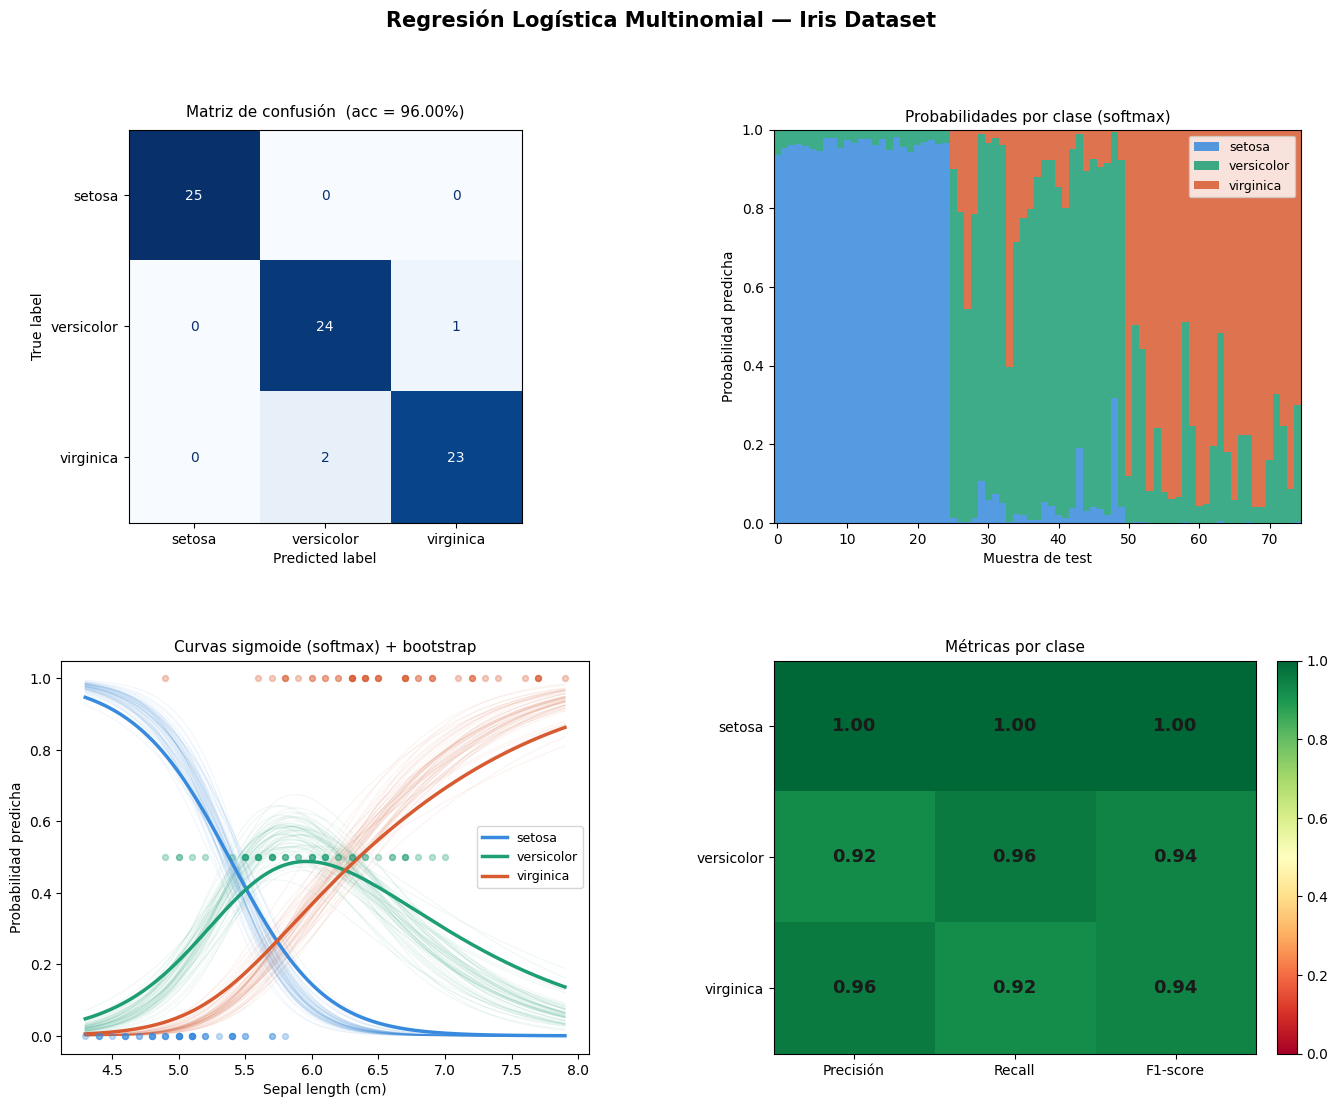

In [ ]:
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.utils import resample
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

# ── Datos ──────────────────────────────────────────────────────────────────────
iris = load_iris()
X, y = iris.data, iris.target
names = iris.target_names
colors = ['#378ADD', '#1D9E75', '#D85A30']

# Split manual
X_train = np.concatenate([X[0:25],   X[50:75],   X[100:125]])
y_train = np.concatenate([y[0:25],   y[50:75],   y[100:125]])
X_test  = np.concatenate([X[25:50],  X[75:100],  X[125:150]])
y_test  = np.concatenate([y[25:50],  y[75:100],  y[125:150]])

# ── Modelo ─────────────────────────────────────────────────────────────────────
model = LogisticRegression(max_iter=1000, solver='lbfgs')
model.fit(X_train, y_train)
y_pred  = model.predict(X_test)
y_proba = model.predict_proba(X_test)
acc     = (y_pred == y_test).mean()

print(f"Accuracy: {acc:.4f}")
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred, target_names=names))

# ── Figura con 4 paneles ───────────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 12), facecolor='white')
fig.suptitle("Regresión Logística Multinomial — Iris Dataset", fontsize=15, fontweight='bold', y=0.98)
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.35, wspace=0.35)

# ── Panel 1: Matriz de confusión ───────────────────────────────────────────────
ax1  = fig.add_subplot(gs[0, 0])
cm   = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=names)
disp.plot(ax=ax1, colorbar=False, cmap='Blues')
ax1.set_title(f"Matriz de confusión  (acc = {acc:.2%})", fontsize=11, pad=10)

# ── Panel 2: Probabilidades predichas (barras apiladas) ───────────────────────
ax2 = fig.add_subplot(gs[0, 1])
idx = np.arange(len(y_test))
bot = np.zeros(len(y_test))
for k, (name, color) in enumerate(zip(names, colors)):
    ax2.bar(idx, y_proba[:, k], bottom=bot, label=name,
            color=color, alpha=0.85, width=1.0, linewidth=0)
    bot += y_proba[:, k]
ax2.set_xlabel("Muestra de test", fontsize=10)
ax2.set_ylabel("Probabilidad predicha", fontsize=10)
ax2.set_title("Probabilidades por clase (softmax)", fontsize=11)
ax2.legend(fontsize=9, loc='upper right')
ax2.set_xlim(-0.5, len(y_test) - 0.5)
ax2.set_ylim(0, 1)

# ── Panel 3: Curva sigmoide — 1 feature + bootstrap ───────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
feat_idx, feat_name = 0, "Sepal length (cm)"

m1d = LogisticRegression(max_iter=1000, solver='lbfgs')
m1d.fit(X_train[:, [feat_idx]], y_train)

x_seq   = np.linspace(X[:, feat_idx].min(), X[:, feat_idx].max(), 300)
p_curve = m1d.predict_proba(x_seq.reshape(-1, 1))

# Bootstrap lines
X_all_1d = X[:, [feat_idx]]
for _ in range(60):
    Xb, yb = resample(X_all_1d, y, n_samples=150)
    mb = LogisticRegression(max_iter=500, solver='lbfgs')
    mb.fit(Xb, yb)
    pb = mb.predict_proba(x_seq.reshape(-1, 1))
    for k, color in enumerate(colors):
        ax3.plot(x_seq, pb[:, k], color=color, alpha=0.07, linewidth=0.8)

for k, (name, color) in enumerate(zip(names, colors)):
    ax3.plot(x_seq, p_curve[:, k], color=color, linewidth=2.5, label=name)

# Puntos reales normalizados a escala 0-1
for k, color in enumerate(colors):
    mask = (y == k)
    ax3.scatter(X[mask, feat_idx], np.full(mask.sum(), k / 2),
                color=color, alpha=0.3, s=18, zorder=2)

ax3.set_xlabel(feat_name, fontsize=10)
ax3.set_ylabel("Probabilidad predicha", fontsize=10)
ax3.set_title("Curvas sigmoide (softmax) + bootstrap", fontsize=11)
ax3.legend(fontsize=9)
ax3.set_ylim(-0.05, 1.05)

# ── Panel 4: Métricas por clase como heatmap ──────────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
report  = classification_report(y_test, y_pred, target_names=names, output_dict=True)
metrics = ['precision', 'recall', 'f1-score']
data    = np.array([[report[n][m] for m in metrics] for n in names])

im = ax4.imshow(data, vmin=0, vmax=1, cmap='RdYlGn', aspect='auto')
ax4.set_xticks(range(3)); ax4.set_xticklabels(['Precisión', 'Recall', 'F1-score'])
ax4.set_yticks(range(3)); ax4.set_yticklabels(names)
ax4.set_title("Métricas por clase", fontsize=11)
for i in range(3):
    for j in range(3):
        ax4.text(j, i, f"{data[i,j]:.2f}", ha='center', va='center',
                 fontsize=13, fontweight='bold',
                 color='white' if data[i, j] < 0.6 else '#1a1a1a')
fig.colorbar(im, ax=ax4, fraction=0.046, pad=0.04)

plt.savefig("iris_logistic_dashboard.png", dpi=150, bbox_inches='tight')
plt.show()

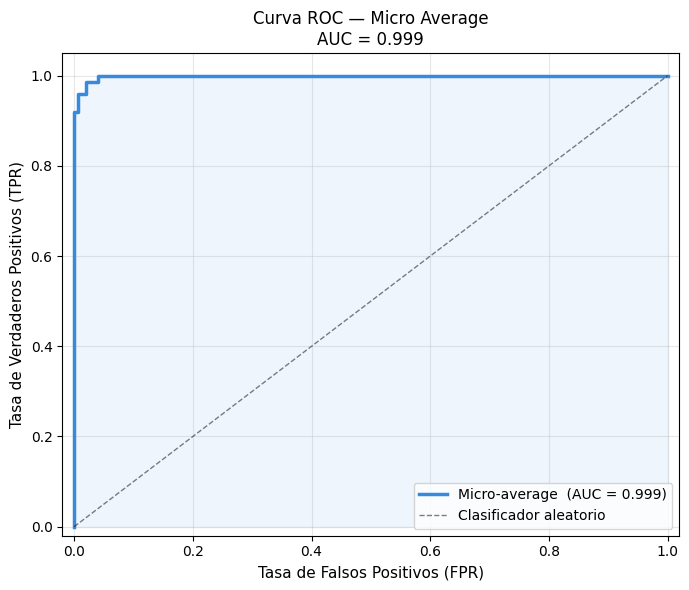

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.preprocessing import label_binarize

# ── Curva ROC — Micro Average (una sola curva total) ──────────────────────────
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])

# Aplanar todas las clases en un solo vector
fpr_micro, tpr_micro, _ = roc_curve(y_test_bin.ravel(), y_proba.ravel())
auc_micro = roc_auc_score(y_test_bin, y_proba, multi_class='ovr', average='micro')

fig, ax = plt.subplots(figsize=(7, 6), facecolor='white')

ax.plot(fpr_micro, tpr_micro, color='#378ADD', linewidth=2.5,
        label=f"Micro-average  (AUC = {auc_micro:.3f})")
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='Clasificador aleatorio')

ax.fill_between(fpr_micro, tpr_micro, alpha=0.08, color='#378ADD')

ax.set_xlabel("Tasa de Falsos Positivos (FPR)", fontsize=11)
ax.set_ylabel("Tasa de Verdaderos Positivos (TPR)", fontsize=11)
ax.set_title(f"Curva ROC — Micro Average\nAUC = {auc_micro:.3f}", fontsize=12)
ax.legend(fontsize=10, loc='lower right')
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.05)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("iris_roc_micro.png", dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
from sklearn.model_selection import cross_validate
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score

# ── Validación cruzada con múltiples métricas ──────────────────────────────────
scoring = {
    'accuracy'  : make_scorer(accuracy_score),
    'precision' : make_scorer(precision_score, average='macro', zero_division=0),
    'recall'    : make_scorer(recall_score,    average='macro', zero_division=0),
    'f1'        : make_scorer(f1_score,        average='macro', zero_division=0),
}

cv      = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = cross_validate(model, X, y, cv=cv, scoring=scoring)

print("Validación Cruzada — 5 Folds")
print("─" * 45)
for metric, key in [('Accuracy',  'test_accuracy'),
                    ('Precisión', 'test_precision'),
                    ('Recall',    'test_recall'),
                    ('F1-score',  'test_f1')]:
    vals = results[key]
    vals_fmt = [f"{v:.4f}" for v in vals]
    print(f"{metric:<12}  {vals.mean():.4f} ± {vals.std():.4f}   {vals_fmt}")

Validación Cruzada — 5 Folds
─────────────────────────────────────────────
Accuracy      0.9667 ± 0.0298   ['1.0000', '0.9667', '0.9333', '1.0000', '0.9333']
Precisión     0.9695 ± 0.0276   ['1.0000', '0.9697', '0.9444', '1.0000', '0.9333']
Recall        0.9667 ± 0.0298   ['1.0000', '0.9667', '0.9333', '1.0000', '0.9333']
F1-score      0.9665 ± 0.0300   ['1.0000', '0.9666', '0.9327', '1.0000', '0.9333']
